Name: Prajakta Mahangare

Roll No: 34

PRN NO.: 12520047

Class: CSE(AI)-SEDA Batch: B2

Assignment no.9

Write a program to do following:
This dataset gives the data of Income and money spent by the customers visiting a shopping mall. The data set contains Customer ID, Gender, Age, Annual Income, Spending Score. Therefore, as a mall owner you need to find the group of people who are the profitable customers for the mall owner. Apply at least two clustering algorithms (based on Spending Score) to find the group of customers.
a.	Apply Data pre-processing
b.	Perform data-preparation (Train-Test Split)
c.	Apply Machine Learning Algorithm
d.	Evaluate Model.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [ ]:
df=pd.read_csv("Mall_Customers.csv", encoding='latin1')
print(df.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


Data Preprocessing

In [ ]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [ ]:
df = df.dropna()

In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


Encode Gender

In [ ]:
le = LabelEncoder()
df['Genre'] = le.fit_transform(df['Genre'])

Select Features

In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

Feature Scaling

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Correlation Heatmap

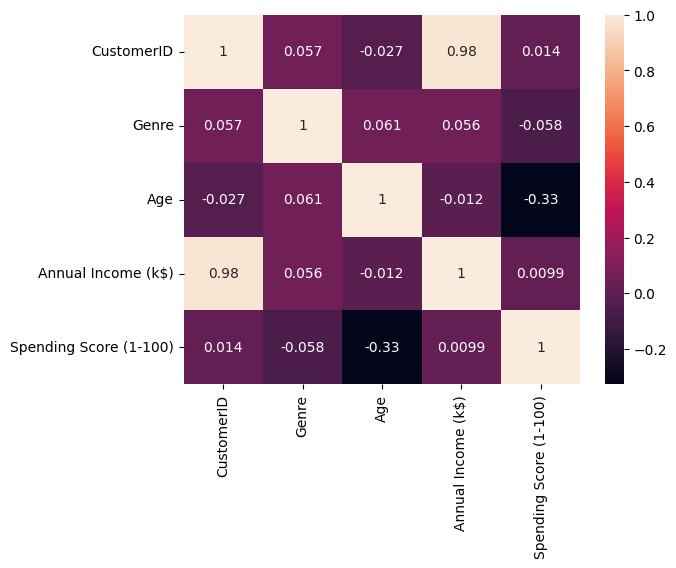

In [ ]:
sns.heatmap(df.corr(), annot=True)
plt.show()

Train-Test Split

In [ ]:
X_train, X_test = train_test_split(X_scaled, test_size=0.2, random_state=42)

K-Means Clustering

Find Optimal Clusters (Elbow Method)



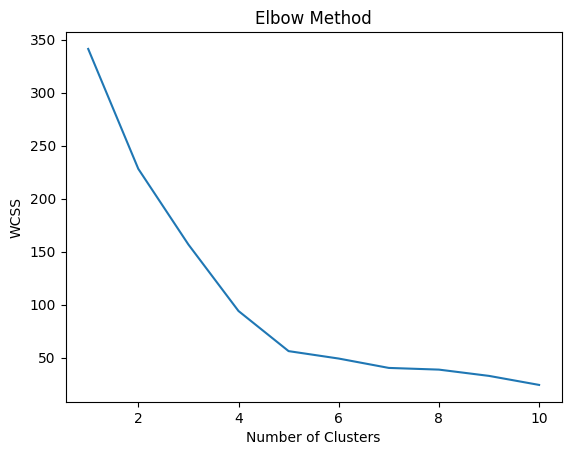

In [ ]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_train)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,11), wcss)
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

Apply KMeans

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

K-Means Visualization (Scatter Plot)

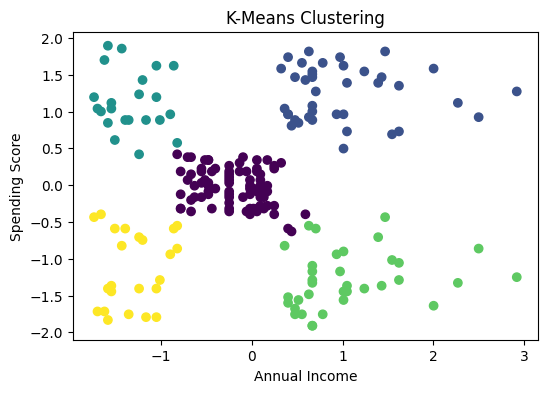

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y_kmeans)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("K-Means Clustering")
plt.show()

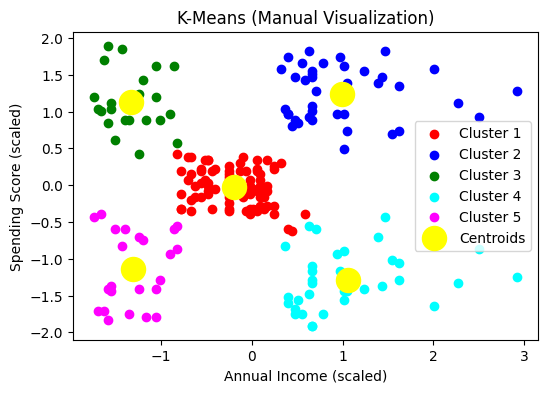

In [ ]:
plt.figure(figsize=(6,4))

plt.scatter(X_scaled[y_kmeans == 0, 0], X_scaled[y_kmeans == 0, 1], c='red', label='Cluster 1')
plt.scatter(X_scaled[y_kmeans == 1, 0], X_scaled[y_kmeans == 1, 1], c='blue', label='Cluster 2')
plt.scatter(X_scaled[y_kmeans == 2, 0], X_scaled[y_kmeans == 2, 1], c='green', label='Cluster 3')
plt.scatter(X_scaled[y_kmeans == 3, 0], X_scaled[y_kmeans == 3, 1], c='cyan', label='Cluster 4')
plt.scatter(X_scaled[y_kmeans == 4, 0], X_scaled[y_kmeans == 4, 1], c='magenta', label='Cluster 5')

# Centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=300, c='yellow', label='Centroids')

plt.title("K-Means (Manual Visualization)")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.legend()
plt.show()


Agglomerative Clustering

Hierarchical Clustering

In [ ]:
hc = AgglomerativeClustering(n_clusters=5)
y_hc = hc.fit_predict(X_scaled)

Hierarchical Visualization

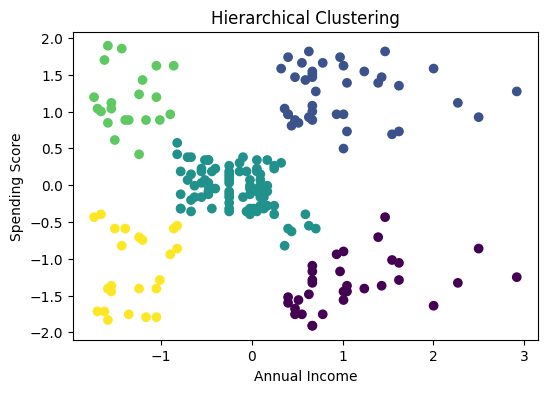

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y_hc)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Hierarchical Clustering")
plt.show()

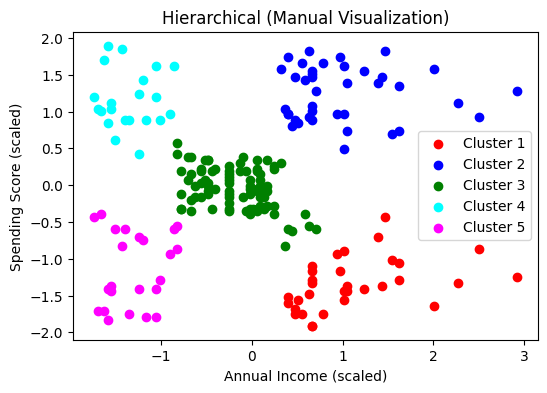

In [ ]:
plt.figure(figsize=(6,4))

plt.scatter(X_scaled[y_hc == 0, 0], X_scaled[y_hc == 0, 1], c='red', label='Cluster 1')
plt.scatter(X_scaled[y_hc == 1, 0], X_scaled[y_hc == 1, 1], c='blue', label='Cluster 2')
plt.scatter(X_scaled[y_hc == 2, 0], X_scaled[y_hc == 2, 1], c='green', label='Cluster 3')
plt.scatter(X_scaled[y_hc == 3, 0], X_scaled[y_hc == 3, 1], c='cyan', label='Cluster 4')
plt.scatter(X_scaled[y_hc == 4, 0], X_scaled[y_hc == 4, 1], c='magenta', label='Cluster 5')

plt.title("Hierarchical (Manual Visualization)")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.legend()
plt.show()


Model Evaluation

Silhouette Score

In [ ]:
kmeans_score = silhouette_score(X_scaled, y_kmeans)
hc_score = silhouette_score(X_scaled, y_hc)

print("K-Means Silhouette Score:", kmeans_score)
print("Hierarchical Silhouette Score:", hc_score)

K-Means Silhouette Score: 0.5546571631111091
Hierarchical Silhouette Score: 0.5538089226688662


Visualization

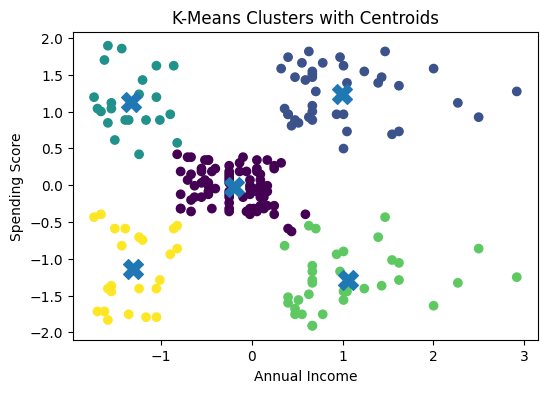

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y_kmeans)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            s=200, marker='X')
plt.title("K-Means Clusters with Centroids")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

In [ ]:
df['Cluster'] = y_kmeans
print(df.groupby('Cluster').mean())

         CustomerID     Genre        Age  Annual Income (k$)  \
Cluster                                                        
0         86.320988  0.407407  42.716049           55.296296   
1        162.000000  0.461538  32.692308           86.538462   
2         23.090909  0.409091  25.272727           25.727273   
3        164.371429  0.542857  41.114286           88.200000   
4         23.000000  0.391304  45.217391           26.304348   

         Spending Score (1-100)  
Cluster                          
0                     49.518519  
1                     82.128205  
2                     79.363636  
3                     17.114286  
4                     20.913043  
